# Частина 3: Аналіз датасету з Kaggle.com

У цьому ноутбуці використовується датасет **Amazon Top 50 Bestselling Books 2009–2019**.


> Назва файлу: `bestsellers with categories.csv`


In [31]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# щоб графіки відображались у ноутбуці
%matplotlib inline

sns.set_theme(style='white')

In [32]:
# Прочитайте csv файл
# Якщо у вас інша назва файлу, змініть її тут:
file_name = 'bestsellers with categories.csv'

df = pd.read_csv(file_name)
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [33]:
# Виведіть розміри датасету
df.shape

(550, 7)

**Відповідь: Про скільки книг зберігає дані датасет?**  
Датасет зберігає дані про **550 записів книг**.

In [34]:
# Змінимо назви стовпців
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


## Первинне дослідження даних

In [35]:
# Кількість пропусків у кожному стовпці
df.isna().sum()

,0
name,0
author,0
user_rating,0
reviews,0
price,0
year,0
genre,0


**Відповідь: Чи є в якихось змінних пропуски?**  
**Відповідь:** Ні.

In [36]:
# Унікальні значення в колонці genre
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

**Відповідь: Які є унікальні жанри?**  
**Відповідь:** `['Fiction', 'Non Fiction']`

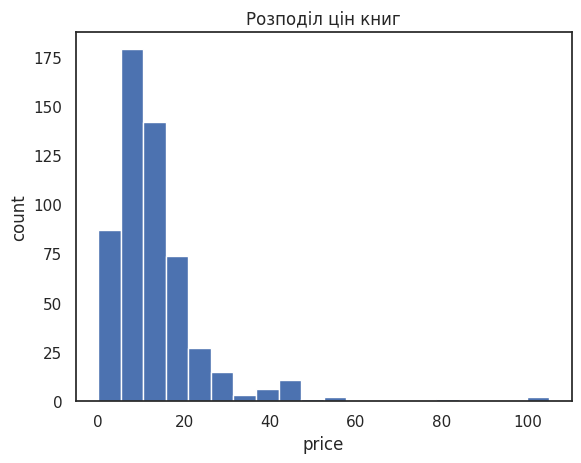

In [37]:
# Розподіл цін
df['price'].plot(kind='hist', bins=20)
plt.xlabel('price')
plt.ylabel('count')
plt.title('Розподіл цін книг')
plt.show()

In [38]:
# Основні характеристики ціни
max_price = df['price'].max()
min_price = df['price'].min()
mean_price = df['price'].mean()
median_price = df['price'].median()

max_price, min_price, mean_price, median_price

(105, 0, np.float64(13.1), 11.0)

**Відповідь: Максимальна ціна?** 105  
**Відповідь: Мінімальна ціна?** 0  
**Відповідь: Середня ціна?** 13.1  
**Відповідь: Медіанна ціна?** 11.0

## Пошук та сортування даних

In [39]:
# Найвищий рейтинг
max_rating = df['user_rating'].max()
max_rating

4.9

In [40]:
# Скільки книг мають такий рейтинг
(df['user_rating'] == max_rating).sum()

np.int64(52)

In [41]:
# Яка книга має найбільше відгуків
df[df['reviews'] == df['reviews'].max()]

,name,author,user_rating,reviews,price,year,genre
534,Where the Crawdads Sing,Delia Owens,4.8,87841,15,2019,Fiction


In [42]:
# Найдорожча книга серед тих, що потрапили до Топ-50 у 2015 році
df_2015 = df[df['year'] == 2015]
df_2015[df_2015['price'] == df_2015['price'].max()]

,name,author,user_rating,reviews,price,year,genre
277,Publication Manual of the American Psychologic...,American Psychological Association,4.5,8580,46,2015,Non Fiction


In [43]:
# Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році
df[(df['genre'] == 'Fiction') & (df['year'] == 2010)].shape[0]

20

In [44]:
# Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках
df[(df['user_rating'] == 4.9) & (df['year'].isin([2010, 2011]))].shape[0]

1

In [45]:
# Відсортуємо книги з 2015 року дешевше за 8 доларів
sorted_2015 = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values('price')
sorted_2015

,name,author,user_rating,reviews,price,year,genre
507,To Kill a Mockingbird,Harper Lee,4.8,26234,0,2015,Fiction
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
206,Knock-Knock Jokes for Kids,Rob Elliott,4.5,3673,4,2015,Non Fiction
111,First 100 Words,Roger Priddy,4.7,17323,4,2015,Non Fiction
210,Laugh-Out-Loud Jokes for Kids,Rob Elliott,4.6,6990,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
224,Love You Forever,Robert Munsch,4.8,18613,5,2015,Fiction
478,The Very Hungry Caterpillar,Eric Carle,4.9,19546,5,2015,Fiction


In [46]:
# Яка книга остання у відсортованому списку?
sorted_2015.tail(1)

,name,author,user_rating,reviews,price,year,genre
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


**Відповідь: Який рейтинг у датасеті найвищий?** 4.9  
**Відповідь: Скільки книг мають такий рейтинг?** 52  
**Відповідь: Яка книга має найбільше відгуків?** *Where the Crawdads Sing*  
**Відповідь: З тих книг, що потрапили до Топ-50 у 2015 році, яка книга найдорожча?** *Publication Manual of the American Psychological Association, 6th Edition*  
**Відповідь: Скільки книг жанру Fiction потрапили до Топ-50 у 2010 році?** 20  
**Відповідь: Скільки книг з рейтингом 4.9 потрапило до рейтингу у 2010 та 2011 роках?** 1  
**Відповідь: Яка книга остання у відсортованому списку?** *Old School (Diary of a Wimpy Kid #10)*

## Агрегування даних та з'єднання таблиць

In [47]:
# Мінімальна та максимальна ціна для кожного жанру
genre_price = df.groupby('genre')['price'].agg(['min', 'max'])
genre_price

,min,max
genre,,
Fiction,0,82
Non Fiction,0,105


**Відповідь: Максимальна ціна для жанру Fiction:** 82  
**Відповідь: Мінімальна ціна для жанру Fiction:** 0  
**Відповідь: Максимальна ціна для жанру Non Fiction:** 105  
**Відповідь: Мінімальна ціна для жанру Non Fiction:** 0

In [48]:
# Кількість книг для кожного автора
authors_books = df.groupby('author')['name'].agg(['count'])
authors_books

,count
author,
Abraham Verghese,2
Adam Gasiewski,1
Adam Mansbach,1
Adir Levy,1
Admiral William H. McRaven,1
...,...
Walter Isaacson,3
William Davis,2
William P. Young,2


In [49]:
authors_books.shape

(248, 1)

In [50]:
# Автор з найбільшою кількістю книг
authors_books[authors_books['count'] == authors_books['count'].max()]

,count
author,
Jeff Kinney,12


**Відповідь: Якої розмірності вийшла таблиця?** (248, 1)  
**Відповідь: Який автор має найбільше книг?** Jeff Kinney  
**Відповідь: Скільки книг цього автора?** 12

In [51]:
# Середній рейтинг для кожного автора
authors_rating = df.groupby('author')['user_rating'].agg(['mean'])
authors_rating

,mean
author,
Abraham Verghese,4.600000
Adam Gasiewski,4.400000
Adam Mansbach,4.800000
Adir Levy,4.800000
Admiral William H. McRaven,4.700000
...,...
Walter Isaacson,4.566667
William Davis,4.400000
William P. Young,4.600000


In [52]:
# Автор з мінімальним середнім рейтингом
authors_rating[authors_rating['mean'] == authors_rating['mean'].min()]

,mean
author,
Donna Tartt,3.9


**Відповідь: У якого автора середній рейтинг мінімальний?** Donna Tartt  
**Відповідь: Який у цього автора середній рейтинг?** 3.9

In [53]:
# Об'єднаємо таблиці
authors_stat = pd.concat([authors_books, authors_rating], axis=1)
authors_stat

,count,mean
author,,
Abraham Verghese,2,4.600000
Adam Gasiewski,1,4.400000
Adam Mansbach,1,4.800000
Adir Levy,1,4.800000
Admiral William H. McRaven,1,4.700000
...,...,...
Walter Isaacson,3,4.566667
William Davis,2,4.400000
William P. Young,2,4.600000


In [54]:
# Відсортуємо за зростанням кількості книг та зростанням рейтингу
authors_stat = authors_stat.sort_values(by=['count', 'mean'], ascending=[True, True])
authors_stat

,count,mean
author,,
Muriel Barbery,1,4.000000
Chris Cleave,1,4.100000
Ian K. Smith M.D.,1,4.100000
Pierre Dukan,1,4.100000
Elizabeth Strout,1,4.200000
...,...,...
American Psychological Association,10,4.500000
Suzanne Collins,11,4.663636
Gary Chapman,11,4.736364


In [55]:
# Який автор перший у списку?
authors_stat.head(1)

,count,mean
author,,
Muriel Barbery,1,4.0


**Відповідь: Який автор перший у списку?** Muriel Barbery

## Додаткова візуалізація

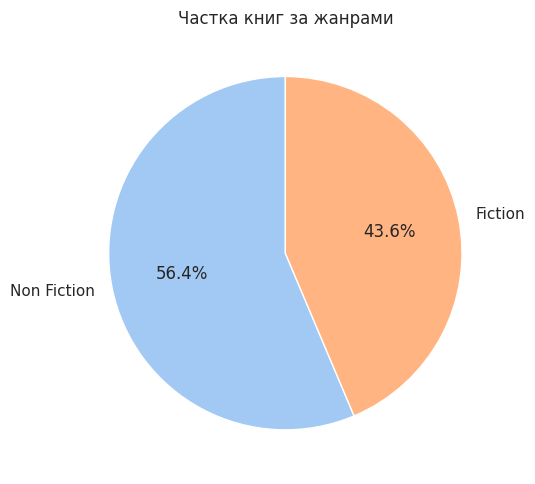

In [56]:
# 2. Кількість книг за жанрами
genre_counts = df['genre'].value_counts()

plt.figure(figsize=(8, 5))
plt.pie(genre_counts.values, labels=genre_counts.index, autopct='%1.1f%%', startangle=90,
        colors=sns.color_palette('pastel'))
plt.title('Частка книг за жанрами')
plt.tight_layout()
plt.show()

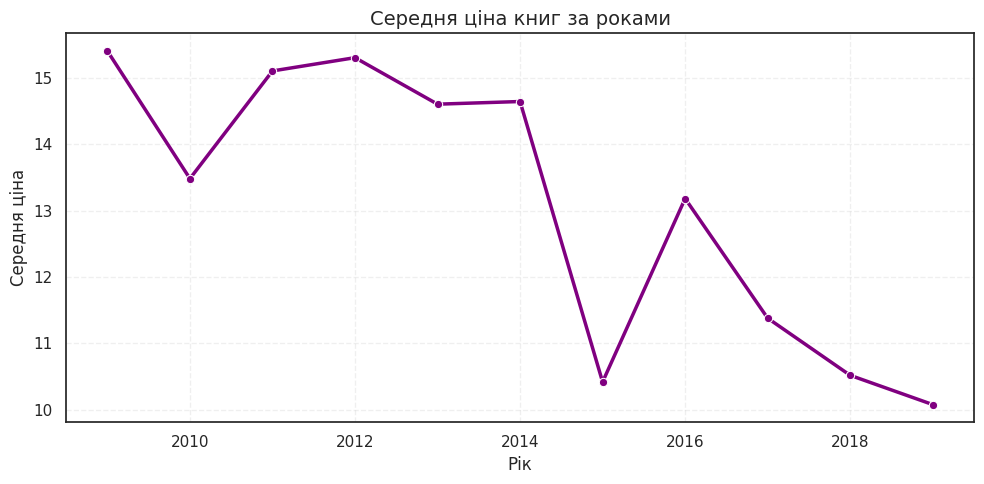

In [57]:
# 3. Середня ціна книг за роками
avg_price_by_year = df.groupby('year')['price'].mean()

plt.figure(figsize=(10, 5))
sns.lineplot(x=avg_price_by_year.index, y=avg_price_by_year.values, marker='o', linewidth=2.5, color='purple')
plt.title('Середня ціна книг за роками', fontsize=14)
plt.xlabel('Рік')
plt.ylabel('Середня ціна')
plt.grid(alpha=0.3, linestyle='--')
plt.tight_layout()
plt.show()

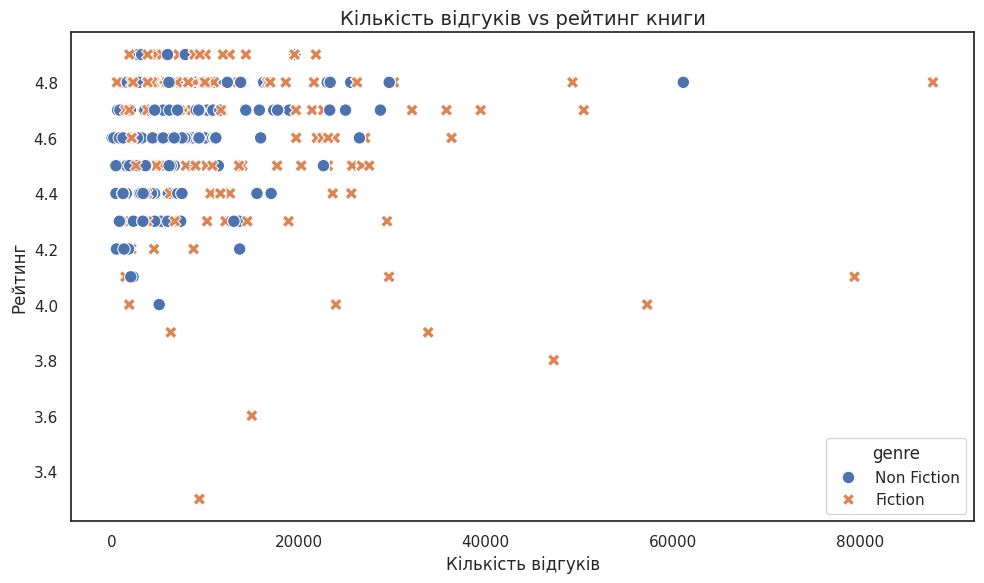

In [58]:
# 4. Залежність між кількістю відгуків і рейтингом
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='reviews', y='user_rating', hue='genre', style='genre', s=80)
plt.title('Кількість відгуків vs рейтинг книги', fontsize=14)
plt.xlabel('Кількість відгуків')
plt.ylabel('Рейтинг')
plt.tight_layout()
plt.show()

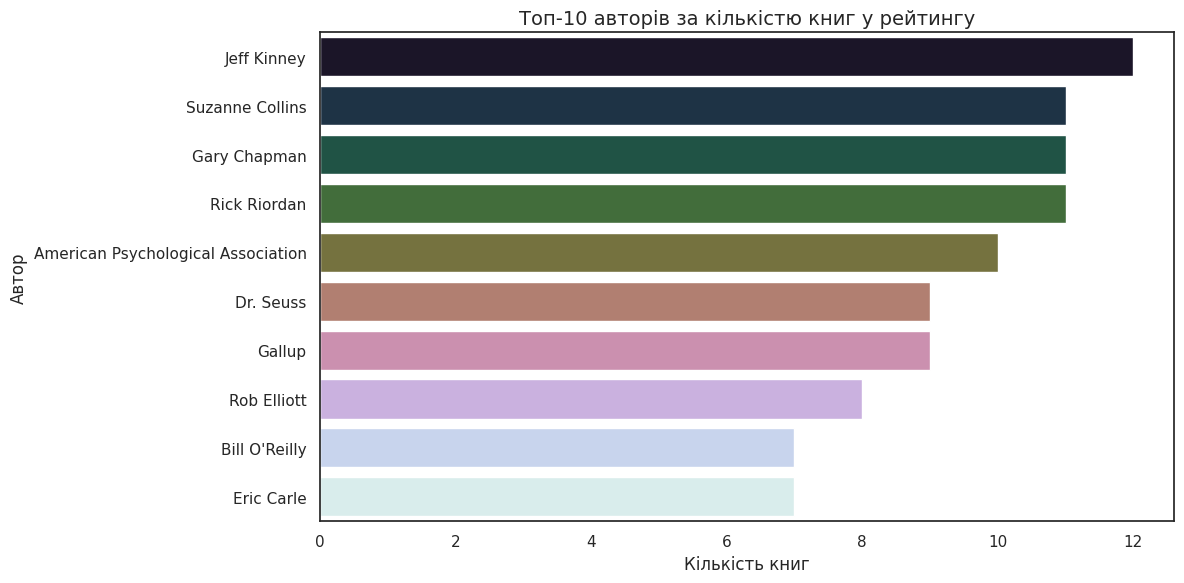

In [59]:
# 5. Топ-10 авторів за кількістю книг у рейтингу
top_authors = df['author'].value_counts().head(10)

plt.figure(figsize=(12, 6))
sns.barplot(x=top_authors.values, y=top_authors.index, hue=top_authors.index, dodge=False, palette='cubehelix', legend=False)
plt.title('Топ-10 авторів за кількістю книг у рейтингу', fontsize=14)
plt.xlabel('Кількість книг')
plt.ylabel('Автор')
plt.tight_layout()
plt.show()

/tmp/ipykernel_3293/1726690125.py:3: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='genre', y='price', palette='coolwarm')


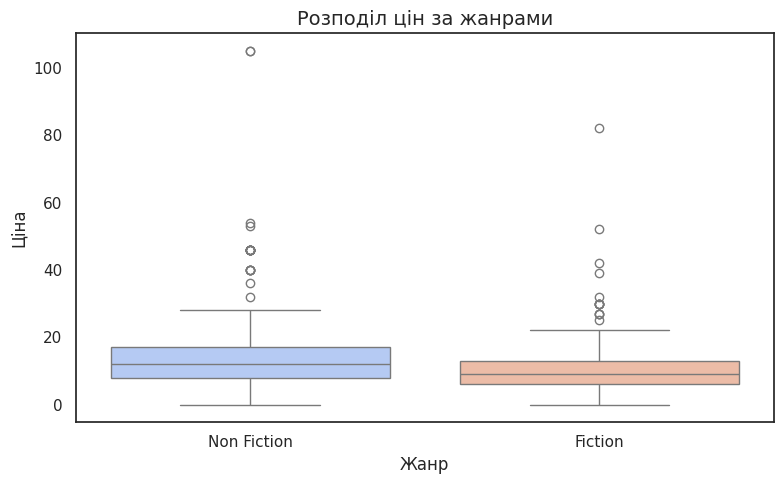

In [60]:
# 6. Boxplot цін за жанрами
plt.figure(figsize=(8, 5))
sns.boxplot(data=df, x='genre', y='price', palette='coolwarm')
plt.title('Розподіл цін за жанрами', fontsize=14)
plt.xlabel('Жанр')
plt.ylabel('Ціна')
plt.tight_layout()
plt.show()

Висновок: Дані показують, що більшість книг мають помірну ціну, а жанр Non Fiction переважає у рейтингу.
